# Generate Figures 9C and 9D

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline

In [2]:
import os

if not os.path.exists('./plots/figure_9'):
    os.makedirs('./plots/figure_9')

In [3]:
data = pd.read_csv('../../data/test_data_big.csv')

In [4]:
1 - sum(data['misclassified_fusion'])/len(data)

0.803125

In [5]:
mis_fusion = data[data['misclassified_fusion'] == True]

In [6]:
mis_fusion.columns

Index(['unique_row_id', 'participant_id', 'date', 'protocol', 'test_split',
       'gender', 'age', 'age_group', 'race', 'filename_smile',
       'filename_speech', 'filename_finger_tapping',
       'filename_finger_tapping_left', 'filename_finger_tapping_right',
       'pred_score_smile', 'pred_score_speech', 'pred_score_finger',
       'pred_score_fusion', 'true_label', 'misclassified_smile',
       'misclassified_speech', 'misclassified_finger', 'misclassified_fusion',
       'uncertain_flag', 'pred_std_fusion', 'neurologist_label_ray',
       'neurologist_label_ruth', 'neurologist_label_jamie'],
      dtype='object')

In [7]:
video_targets = mis_fusion.drop(columns=['unique_row_id', 'date', 'protocol', 'test_split', 'age', 'race',
                                         'uncertain_flag', 'neurologist_label_ray', 'neurologist_label_ruth',
                                         'neurologist_label_jamie'])

In [8]:
video_targets.to_csv('../../data/video_abmornality_detection.csv')

In [9]:
abnorm = pd.read_csv('../../data/video_abmornality_detection_results.csv')
labels = abnorm.iloc[:63, :]

In [10]:
labels.columns

Index(['participant_id', 'gender', 'age_group', 'filename_finger_tapping',
       'filename_finger_tapping_left', 'filename_finger_tapping_right',
       'filename_smile', 'filename_speech', 'true_label',
       'misclassified_smile', 'pred_score_smile', 'misclassified_speech',
       'pred_score_speech', 'misclassified_finger', 'pred_score_finger',
       'misclassified_fusion', 'pred_score_fusion',
       'finger_not_follow_instruction', 'finger_insufficient_video_quality',
       'finger_no_observed_pd_symptom', 'finger_other_symp_unrelated_to_pd',
       'finger_pd_symptoms', 'finger_unexplainable_err',
       'smile_not_follow_instruction', 'smile_insufficient_video_quality',
       'smile_no_observed_pd_symptom', 'smile_other_symp_unrelated_to_pd',
       'smile_pd_symptoms', 'smile_unexplainable_err',
       'speech_not_follow_instruction', 'speech_insufficient_video_quality',
       'speech_no_observed_pd_symptom', 'speech_other_symp_unrelated_to_pd',
       'speech_pd_symptoms

In [11]:
fp = labels[labels['true_label'] == 0]
fn = labels[labels['true_label'] == 1]

In [12]:
len(fp)

38

In [13]:
len(fn)

25

In [14]:
# false positive abnormalities distribution
fp_fig = fp.drop(columns=['participant_id', 'gender', 'age_group', 'filename_finger_tapping',
       'filename_finger_tapping_left', 'filename_finger_tapping_right',
       'filename_smile', 'filename_speech', 'true_label',
       'misclassified_smile', 'pred_score_smile', 'misclassified_speech',
       'pred_score_speech', 'misclassified_finger', 'pred_score_finger',
       'misclassified_fusion', 'pred_score_fusion', 'Annotator Note', 
       'finger_no_observed_pd_symptom', 'smile_no_observed_pd_symptom', 'speech_no_observed_pd_symptom'])
fp_fig.columns = [
    'Finger - Not Following Instruction',
    'Finger - Low Video Quality',
    'Finger - Symptoms Unrelated to PD',
    'Finger - Observed PD Symptoms',
    'Finger - Unexplainable Error',
    'Smile - Not Following Instruction',
    'Smile - Low Video Quality',
    'Smile - Symptoms Unrelated to PD',
    'Smile - Observed PD Symptoms',
    'Smile - Unexplainable Error',
    'Speech - Not Following Instruction',
    'Speech - Low Video Quality',
    'Speech - Symptoms Unrelated to PD',
    'Speech - Observed PD Symptoms',
    'Speech - Unexplainable Error'
]
col_sums = fp_fig.sum()

In [15]:
# false negative abnormalities distribution
fn_fig = fn.drop(columns=['participant_id', 'gender', 'age_group', 'filename_finger_tapping',
       'filename_finger_tapping_left', 'filename_finger_tapping_right',
       'filename_smile', 'filename_speech', 'true_label',
       'misclassified_smile', 'pred_score_smile', 'misclassified_speech',
       'pred_score_speech', 'misclassified_finger', 'pred_score_finger',
       'misclassified_fusion', 'pred_score_fusion', 'Annotator Note', 
       'finger_pd_symptoms', 'smile_pd_symptoms', 'speech_pd_symptoms'])
fn_fig.columns = [
    'Finger - Not Following Instruction',
    'Finger - Low Video Quality',
    'Finger - No PD Symptoms Observed',
    'Finger - Symptoms Unrelated to PD',
    'Finger - Unexplainable Error',
    'Smile - Not Following Instruction',
    'Smile - Low Video Quality',
    'Smile - No PD Symptoms Observed',
    'Smile - Symptoms Unrelated to PD',
    'Smile - Unexplainable Error',
    'Speech - Not Following Instruction',
    'Speech - Low Video Quality',
    'Speech - No PD Symptoms Observed',
    'Speech - Symptoms Unrelated to PD',
    'Speech - Unexplainable Error'
]
col_sums_fn = fn_fig.sum()

In [16]:
df = fn_fig.copy()

error_categories = [
    'Not Following Instruction',
    'Low Video Quality',
    'No PD Symptoms Observed',
    'Symptoms Unrelated to PD',
    'Unexplainable Error'
]

task_groups = {
    'All tasks': ['Finger', 'Smile', 'Speech'],
    'Finger + Smile': ['Finger', 'Smile'],
    'Finger + Speech': ['Finger', 'Speech'],
    'Smile + Speech': ['Smile', 'Speech'],
    'Finger': ['Finger'],
    'Smile': ['Smile'],
    'Speech': ['Speech']
}

data_matrix = []

for err in error_categories:
    row = []
    for task_combo in task_groups.values():
        cols = [f'{task} - {err}' for task in task_combo]
        values = df[cols].mean(axis=1)  # Average across task columns
        row.append(np.mean(values) * 100)  # Overall percentage
    data_matrix.append(row)

data = np.array(data_matrix)

In [17]:
plt.cm.Pastel1(np.linspace(0, 1, 7))[[0, 1, 2, 3, 5]]

array([[0.98431373, 0.70588235, 0.68235294, 1.        ],
       [0.70196078, 0.80392157, 0.89019608, 1.        ],
       [0.87058824, 0.79607843, 0.89411765, 1.        ],
       [0.99607843, 0.85098039, 0.65098039, 1.        ],
       [0.99215686, 0.85490196, 0.9254902 , 1.        ]])

In [18]:
def _plot_horizontal_error_bars(data, task_groups, error_categories, title, savepath, 
                                error_colors = plt.cm.Pastel1(np.linspace(0, 1, 8))[[2, 1, 0, 3, 4]],
                                value_format="{:.0f}%", percentage=True):

    n_groups = len(task_groups)
    fig, axs = plt.subplots(1, n_groups-3, figsize=(4 * n_groups-3, 6), sharey=True)
    group_names = list(task_groups.keys())
    group_names = ["Finger-tapping" if name == "Finger" else name for name in group_names]
    y_pos = np.arange(len(error_categories))[::-1]

    for j, ax in enumerate(axs):
        if j>0:
            i = j+3
        else:
            i = j
        
        vals = data[:, i]
        for y, vt, color in zip(y_pos, vals, error_colors):
            n, v = vt
            ax.barh(y, v, color=color, edgecolor='black', height=0.8)
            if percentage:
                ax.text(v + 1, y, f'{(int)(n)} ({v:.0f}%)', va='center', fontsize=18)
            else:
                ax.text(v + np.max(data) * 0.01, y, value_format.format(int(v)), va='center', fontsize=18)
            
        ax.set_yticks(y_pos)
        ax.set_yticklabels(error_categories, fontsize=22)
        ax.tick_params(axis='x', labelsize=22)

        ax.set_xlim(0, np.max(data) * 1.1)
        ax.set_title(group_names[i], fontsize=24)

    axs[0].set_ylabel("Error Type", fontsize=24)
    axs[2].set_xlabel("Coverage (%)", fontsize=24)
    #fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(savepath)
    plt.show()

In [19]:
def _plot_horizontal_error_bars_v2(data_and, data_or, task_groups, error_categories, title, savepath, 
                                error_colors = plt.cm.Pastel1(np.linspace(0, 1, 8))[[2, 1, 0, 3, 4]],
                                value_format="{:.0f}%", percentage=True):

    n_groups = len(task_groups)
    fig, axs = plt.subplots(1, n_groups-2, figsize=(3.5 * n_groups-2, 6), sharey=True)
    group_names = list(task_groups.keys())
    group_names = ["All Three Tasks", "Any of the Three Tasks", "XX", "XXX", "Finger-tapping", "Smile", "Speech"]
    #group_names = ["Finger-tapping" if name == "Finger" else name for name in group_names]
    y_pos = np.arange(len(error_categories))[::-1]

    for j, ax in enumerate(axs):
        if j==0:
            vals = data_and[:, 0]
            i = j
        elif j==1:
            vals = data_or[:, 0]
            i = j
        else:
            i = j+2
            vals = data_and[:, i]

        for y, vt, color in zip(y_pos, vals, error_colors):
            n, v = vt
            ax.barh(y, v, color=color, edgecolor='black', height=0.8)
            if percentage:
                ax.text(v + 1, y, f'{(int)(n)} ({v:.0f}%)', va='center', fontsize=18)
            else:
                ax.text(v + np.max(data) * 0.01, y, value_format.format(int(v)), va='center', fontsize=18)
            
        ax.set_yticks(y_pos)
        ax.set_yticklabels(error_categories, fontsize=22)
        ax.tick_params(axis='x', labelsize=22)

        ax.set_xlim(0, np.max(data) * 1.1)
        ax.set_title(group_names[i], fontsize=24)

    axs[0].set_ylabel("Error Type", fontsize=24)
    axs[2].set_xlabel("Coverage (%)", fontsize=24)
    #fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(savepath)
    plt.show()

In [20]:
def plot_error_bar_logical_or(df, task_groups, error_categories, csv_keys, saveto,
                              title='Video Abnormal Labels (Logical OR)'):
    import numpy as np
    data = []
    for key in csv_keys:
        row_vals = []
        for task_list in task_groups.values():
            cols = [f'{task} - {key}' for task in task_list]
            cond = (df[cols] == 1).any(axis=1)
            percentage = cond.sum() / len(df) * 100
            row_vals.append((cond.sum(), percentage))
        data.append(row_vals)
    data = np.array(data)
    _plot_horizontal_error_bars(data, task_groups, error_categories, title, saveto)

In [21]:
def plot_error_bar_strict_and(df, task_groups, error_categories, csv_keys, saveto, 
                              title='Video Abnormal Labels (Strict AND)'):
    import numpy as np
    data = []
    for key in csv_keys:
        row_vals = []
        for task_list in task_groups.values():
            cols = [f'{task} - {key}' for task in task_list]
            cond = (df[cols] == 1).all(axis=1)
            percentage = cond.sum() / len(df) * 100
            row_vals.append((cond.sum(), percentage))
        data.append(row_vals)
    data = np.array(data)
    _plot_horizontal_error_bars(data, task_groups, error_categories, title, saveto)

In [22]:
def plot_error_bar(df, task_groups, error_categories, csv_keys, saveto, 
                              title='Video Abnormal Labels (AND OR)'):
    import numpy as np
    data_and = []
    for key in csv_keys:
        row_vals = []
        for task_list in task_groups.values():
            cols = [f'{task} - {key}' for task in task_list]
            cond = (df[cols] == 1).all(axis=1)
            percentage = cond.sum() / len(df) * 100
            row_vals.append((cond.sum(), percentage))
        data_and.append(row_vals)
    data_and = np.array(data_and)

    data_or = []
    for key in csv_keys:
        row_vals = []
        for task_list in task_groups.values():
            cols = [f'{task} - {key}' for task in task_list]
            cond = (df[cols] == 1).any(axis=1)
            percentage = cond.sum() / len(df) * 100
            row_vals.append((cond.sum(), percentage))
        data_or.append(row_vals)
    data_or = np.array(data_or)

    _plot_horizontal_error_bars_v2(data_and, data_or, task_groups, error_categories, title, saveto)

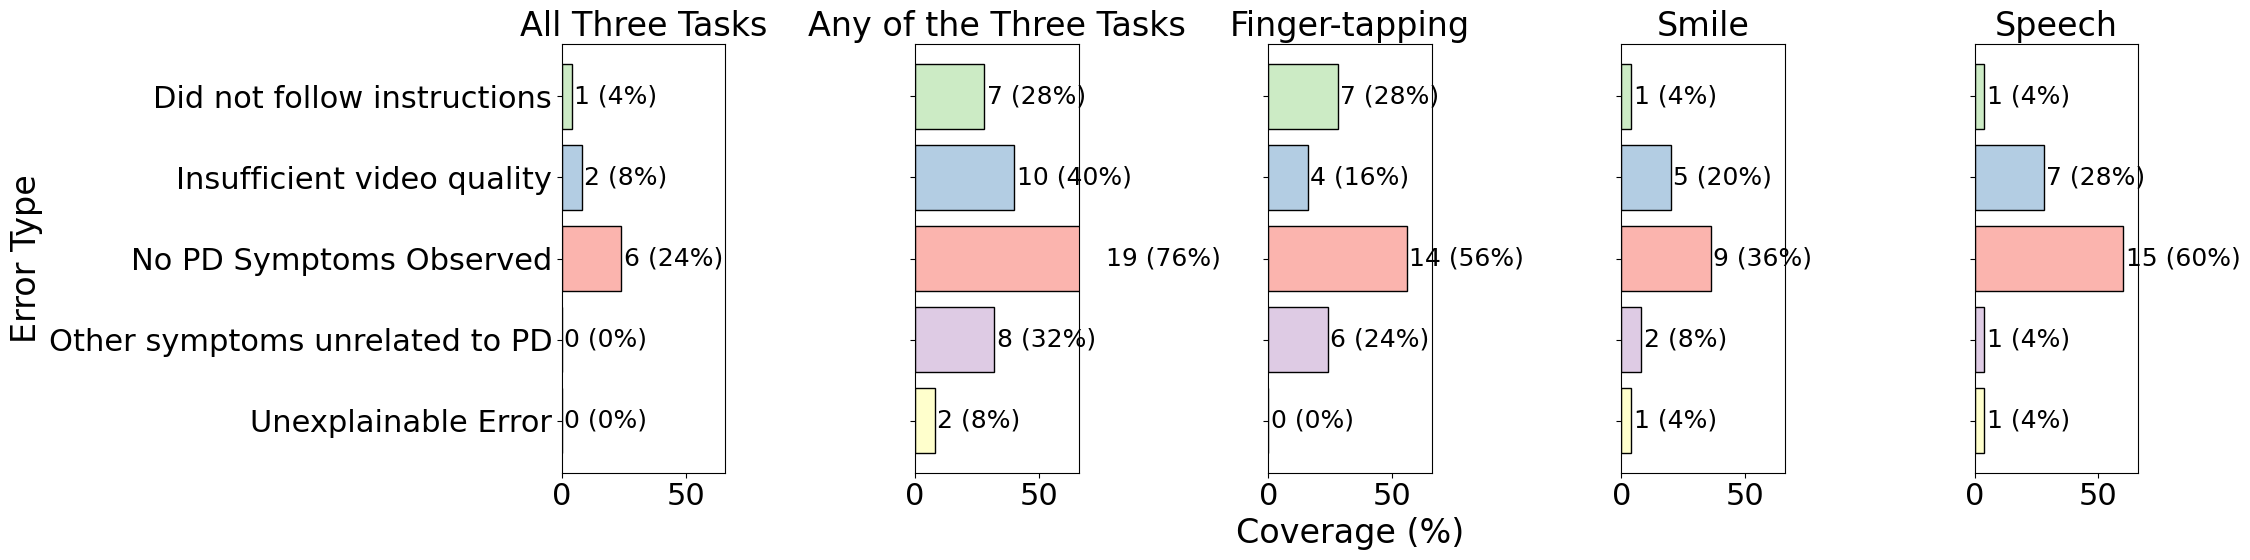

In [23]:
# fn
dffn = fn_fig.copy()
error_categories = [
    'Did not follow instructions',
    'Insufficient video quality',
    'No PD Symptoms Observed',
    'Other symptoms unrelated to PD',
    'Unexplainable Error'
]

csv_keys = [
    'Not Following Instruction',
    'Low Video Quality',
    'No PD Symptoms Observed',
    'Symptoms Unrelated to PD',
    'Unexplainable Error'
]

task_groups = {
    'All tasks': ['Finger', 'Smile', 'Speech'],
    'Finger + Smile': ['Finger', 'Smile'],
    'Finger + Speech': ['Finger', 'Speech'],
    'Smile + Speech': ['Smile', 'Speech'],
    'Finger': ['Finger'],
    'Smile': ['Smile'],
    'Speech': ['Speech']
}
# plot_error_bar_average(dffn, task_groups, error_categories, csv_keys, title='FN Video Abnormalities (Average)',
#                       saveto='figures/False-Negative-Summary-Average.png')
# plot_error_bar_logical_or(dffn, task_groups, error_categories, csv_keys, title='FN Video Abnormalities (OR)',
#                       saveto='figures/False-Negative-Summary-OR.png')
# plot_error_bar_strict_and(dffn, task_groups, error_categories, csv_keys, title='FN Video Abnormalities (AND)',
#                       saveto='False-Negative-Summary-AND.png')
plot_error_bar(dffn, task_groups, error_categories, csv_keys, title='FN Video Abnormalities', saveto='./plots/figure_9/False-Negative-Summary.png')

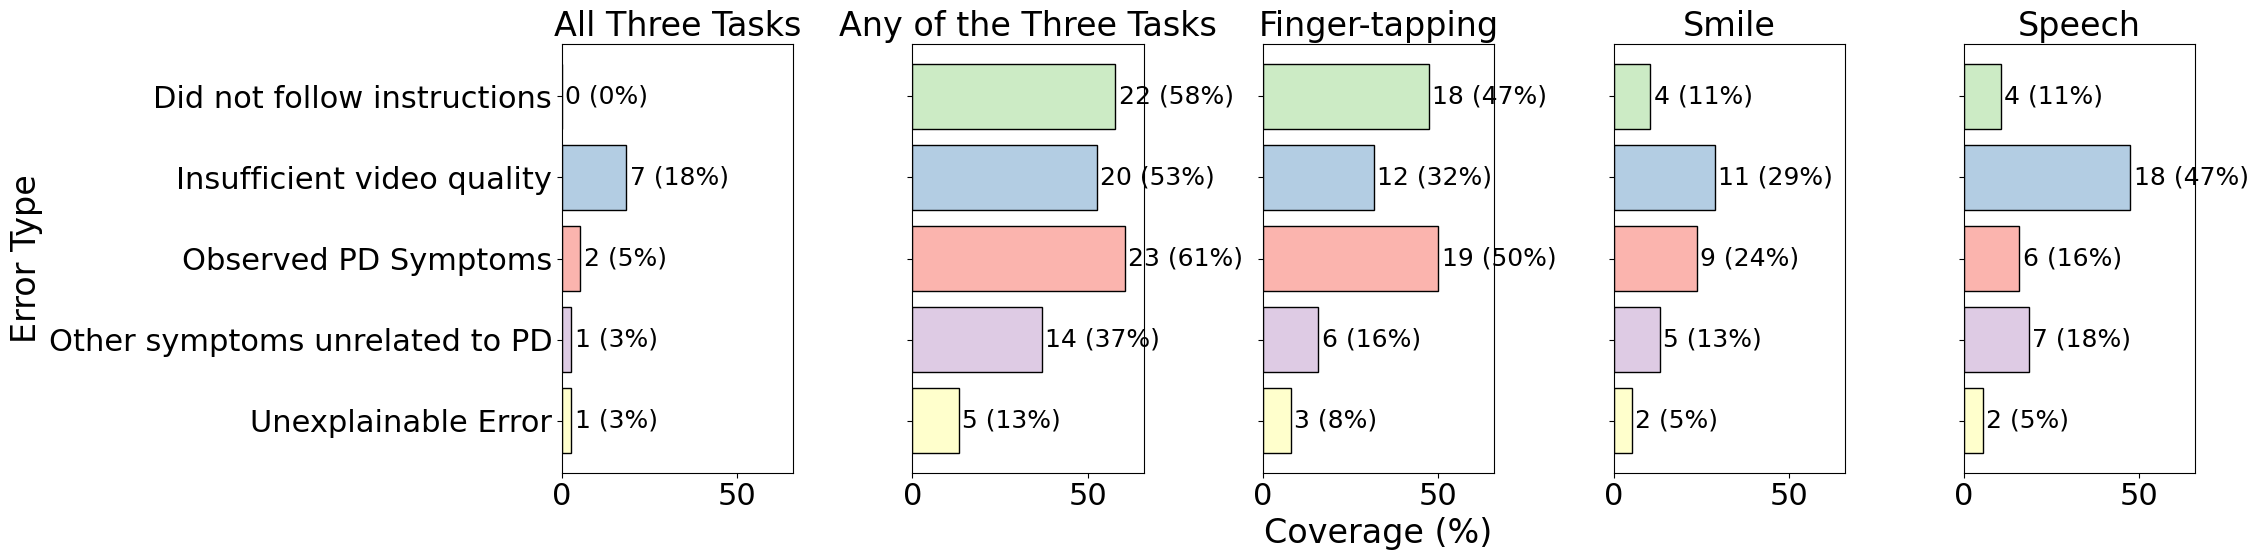

In [24]:
# fp
dffp = fp_fig.copy()
error_categories = [
    'Did not follow instructions',
    'Insufficient video quality',
    'Observed PD Symptoms',
    'Other symptoms unrelated to PD',
    'Unexplainable Error'
]

csv_keys = [
    'Not Following Instruction',
    'Low Video Quality',
    'Observed PD Symptoms',
    'Symptoms Unrelated to PD',
    'Unexplainable Error'
]

# plot_error_bar_average(dffp, task_groups, error_categories, csv_keys, title='FP Video Abnormalities (Average)',
#                       saveto='figures/False-Positive-Summary-Average.png')
# plot_error_bar_logical_or(dffp, task_groups, error_categories, csv_keys, title='FP Video Abnormalities (OR)',
#                       saveto='figures/False-Positive-Summary-OR.png')
# plot_error_bar_strict_and(dffp, task_groups, error_categories, csv_keys, title='FP Video Abnormalities (AND)',
#                      saveto='False-Positive-Summary-AND.png')
plot_error_bar(dffp, task_groups, error_categories, csv_keys, title='FP Video Abnormalities (AND OR)',
                      saveto='./plots/figure_9/False-Positive-Summary.png')